**Autor:** Francisco Javier Cristóbal Fernández  

## **Campaña "Seguro Vivienda" de compañía Nordik Seguros**

El objetivo de este nuevo estudio es agrupar a los clientes en distintos "clusters" para que el equipo comercial intente determinar posteriormente qué tipo de productos se adaptan mejor a cada uno de los clusters obtenidos.

Se desconoce el número de clusters óptimo, por lo que se explorará un rango de valores razonable, respaldando las conclusiones con métricas y gráficas apropiadas.

## **PROCESO DETALLADO**

El objetivo es realizar una **segmentación no supervisada** de clientes utilizando un algoritmo de clustering, para agruparlos en un número óptimo de clústeres. Esto se logrará a partir de los datos transaccionales y geográficos, buscando obtener grupos de clientes homogéneos internamente y heterogéneos entre sí.

Para ello, el ejercicio se desarrollará siguiendo una secuencia lógica de **11 pasos** que abarcan desde la preparación de datos hasta la validación del modelo:

| # | Fase | Tarea | Justificación |
| :---: | :--- | :--- | :--- |
| **1** | **Preparación** | **Cruce de Datos** | Unir dataset de clientes con las características geográficas (`Zonas.csv`) para centralizar la información. |
| **2** | **Preprocesamiento** | **Exclusión de la Variable Objetivo** | Separar la variable que indica si el cliente contrató el seguro. El clustering es no supervisado; esta variable se usará solo *a posteriori* para la interpretación. |
| **3** | **Análisis Exploratorio de Datos (EDA)** | **Estudio Inicial del Dataset** | Explorar la estructura, tipos de datos y distribución de las variables para comprender el dataset e identificar posibles anomalías. |
| **4** | **Preprocesamiento** | **Tratamiento de Variables Categóricas** | Convertir variables categóricas a un formato numérico. Se explorará **One Hot Encoding** y técnicas de *binning* para manejar variables con alta cardinalidad. |
| **5** | **Preprocesamiento** | **Identificación y Tratamiento de Outliers** | Detectar valores atípicos en variables numéricas. Se plantea **aislar los outliers** creando un clúster separado para evitar que distorsionen los centroides de los clústeres principales. |
| **6** | **Preprocesamiento** | **Transform/Escalado de Variables** | Normalizar las variables numéricas usando **`StandardScaler` ($\mu=0, \sigma=1$)**. Esto es crucial, ya que los métodos de clustering son sensibles a las diferentes escalas. |
| **7** | **Dimensionalidad** | **Reducción de Dimensionalidad (opcional)** | Estudiar si es adecuado aplicar un método como **Análisis de Componentes Principales (PCA)** para simplificar el modelo y aumentar la eficiencia del clustering, maximizando la varianza. |
| **8** | **Modelado** | **Selección del K Óptimo** | Utilizar el **Método del Codo** y el **Coeficiente de Silhouette** para determinar el número ideal de clústeres (*K*) que maximiza la cohesión interna y la separación externa. |
| **9** | **Modelado** | **Aplicación de K-Means** | Entrenar el modelo K-Means con el *K* óptimo. Se ajustarán hiperparámetros como el número de inicializaciones (`n_init`) para mejorar la robustez del resultado. |
| **10** | **Evaluación e Interpretación** | **Evaluación e interpretación de los clústers** | Reintroducir la variable objetivo para **interpretar** el significado de cada clúster. Se calculará la **Tasa de Conversión promedio** por clúster para evaluar su potencial predictivo en la segmentación. |
| **11** | **Evaluación e interpretación** | **Aplicación del modelo en nuevos clientes** | **Aplicar el modelo entrenado al conjunto de test `Clientes_test.csv`** para evaluar cómo se distrubuyen los nuevos clientes dentro de los segmentos definidos.
| **12** | **Modelado (Opcional)** | **Exploración de Métodos Alternativos** | Evaluar si es necesario o no la implementación de otros enfoques de clustering como **Clustering Jerárquico**, **DBScan** o **Gaussian Mixture** en función de los resultados obtenidos. |

## **FASE 1: Cruce de datos**

In [1]:
import os

if os.path.exists('/content') and not os.getcwd().endswith('notebooks'):
    if not os.path.exists('/content/notebooks'):
        os.makedirs('/content/notebooks')
    os.chdir('/content/notebooks')

In [2]:
datos_path = "../data"

Se ha definido la variable de datos_path = "." para indicar que los archivos de datos se encuentran en el mismo directorio que el cuaderno de trabajo. Esta opción permite que el notebook sea portátil y reproducible, ya que no depende de rutas absolutas del sistema, que solo funcionarían en el entorno personal de cada uno.

De esta forma, cualquier persona podrá ejecutar el cuaderno sin necesidad de modificar la ruta, siempre que los archivos de datos estén en la misma carpeta que el notebook.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

import os

%matplotlib inline

clientes_file = "Clientes_train.csv"
zonas_file = "Zonas.csv"

clientes = pd.read_csv(os.path.join(datos_path, clientes_file), sep='\t')
zonas = pd.read_csv(os.path.join(datos_path, zonas_file), sep='\t')

datos = pd.merge(clientes, zonas, on="ID_Zona", how="inner")

La primera etapa del proceso consiste en **cargar** los *datasets* de clientes y zonas para consolidar toda la información relevante en una única tabla de trabajo.

**Carga de Datos**

Se utilizan las librerías estándar de manipulación de datos (`pandas` y `os`) para leer los archivos:

* **`Clientes_train.csv`**: Contiene la información transaccional y demográfica de cada cliente, además de la variable objetivo (`Seguro_Vivienda`).
* **`Zonas.csv`**: Contiene características geográficas y socioeconómicas asociadas a cada zona.

Ambos archivos se cargan especificando el separador de tabulación (`sep='\t'`).

**Cruce de Datos**

Para obtener una visión completa de cada cliente, se realiza una **unión interna** (`pd.merge(..., how="inner")`) entre el *DataFrame* de clientes y el *DataFrame* de zonas.

El cruce se efectúa utilizando la variable **`ID_Zona`** como clave común. Este paso asegura que solo se consideren aquellos clientes para los que se tiene información de zona, resultando en el *DataFrame* **`datos`**. Este *DataFrame* unificado es la base para las fases posteriores de preprocesamiento y modelado.

## **FASE 2: Exclusión de la variable objetivo**

In [4]:
targets = datos["Seguro_Vivienda"]
variables = datos.drop(["Seguro_Vivienda"], axis=1, inplace=False)

El objetivo de este ejercicio es realizar una **segmentación no supervisada** utilizando algoritmos como K-Means. En el aprendizaje no supervisado, el modelo debe encontrar patrones y estructuras ocultas en los datos **sin la guía** de una variable de resultado predefinida.

Por esta razón, la variable **`Seguro_Vivienda`** (nuestra variable objetivo), que indica si el cliente contrató o no el seguro, debe ser **excluida** del *DataFrame* que se utilizará para el *clustering*.

Para ello, se han realizado las siguientes acciones en el código anterior:

1.  **Aislamiento de la Variable Objetivo:** La columna `Seguro_Vivienda` se extrae del *DataFrame* unificado (`datos`) y se almacena en una estructura separada llamada **`targets`**.
2.  **Creación del *DataFrame* de Características:** Se crea el *DataFrame* **`variables`**, que es una copia de `datos` pero sin la columna `Seguro_Vivienda`. Este *DataFrame* contiene únicamente las características o *features* que se utilizarán para entrenar el modelo de *clustering*.

Esta variable `targets` se **reintroducirá** únicamente al final del proceso (**Paso 10**) para la **interpretación** y validación de los clústeres obtenidos.

## **FASE 3: Estudio inicial del dataset**

Hacemos un estudio de los datos con el objetivo de comprenderlos y encontrar en ellos posibles anomalías. Empezamos por una inspección visual de una muestra de filas de la tabla:

In [5]:
variables.shape

(2927, 28)

In [6]:
variables.head()

,ID_Cliente,Fecha_Nacimiento,Fecha_Alta,Sexo,ID_Zona,Productos_Vida,Productos_Vehiculos,Productos_Otros,Gasto_Vida,Gasto_Vehiculos,...,Poblacion_Funcionario,Poblacion_Trabajador_Cualificado,Poblacion_Trabajador_No_Cualificado,Vivienda_Propiedad,Vivienda_Alquiler,Medico_Seguro_Privado,Medico_Seguridad_Social,Ingresos_Mas_De_40000,Ingresos_De_20000_Hasta_40000,Ingresos_Hasta_20000
0,C3088,29/03/1968,27/03/1989,Mujer,Z1143,0,1,0,0.00,617.55,...,28.17,21.01,27.13,71.34,28.66,32.77,67.23,2.23,1.47,96.30
1,C2975,08/12/1978,26/12/1998,Mujer,Z1201,2,0,1,973.61,0.00,...,41.51,11.54,9.42,92.04,7.96,43.84,56.16,0.00,3.38,96.62
2,C0840,31/07/1950,19/04/1972,Hombre,Z1122,0,1,2,0.00,3572.01,...,18.30,34.78,41.43,56.37,43.63,17.48,82.52,0.00,1.72,98.28
3,C0461,29/07/1945,21/07/1967,Mujer,Z1190,1,1,2,87.91,4558.71,...,57.13,22.28,1.54,93.38,6.62,44.57,55.43,6.76,6.39,86.84
4,C2777,17/10/1955,22/02/1976,Hombre,Z1344,0,1,0,0.00,4289.61,...,53.30,1.92,12.61,12.63,87.37,45.32,54.68,21.34,27.01,51.66


In [7]:
variables.describe()

,Productos_Vida,Productos_Vehiculos,Productos_Otros,Gasto_Vida,Gasto_Vehiculos,Gasto_Otros,Tipo_Familia,Tipo_Pareja,Tipo_Soltero,Educacion_Superior,...,Poblacion_Funcionario,Poblacion_Trabajador_Cualificado,Poblacion_Trabajador_No_Cualificado,Vivienda_Propiedad,Vivienda_Alquiler,Medico_Seguro_Privado,Medico_Seguridad_Social,Ingresos_Mas_De_40000,Ingresos_De_20000_Hasta_40000,Ingresos_Hasta_20000
count,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,...,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000,2927.000000
mean,0.080287,0.750940,1.066279,37.133915,1583.312689,273.471145,47.392026,34.010779,18.597458,14.136502,...,29.345565,22.355572,26.771343,54.007017,45.992983,27.863485,72.136515,1.449713,6.700150,91.850126
std,0.365148,0.795887,1.001220,289.125502,2008.636888,741.281246,24.955844,20.001426,20.498031,18.661422,...,21.739949,20.322406,21.439939,37.375465,37.375465,24.390093,24.390093,5.362351,12.187754,14.078293
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,29.410000,19.980000,0.000000,0.000000,...,15.230000,3.880000,9.420000,14.900000,8.175000,7.275000,56.530000,0.000000,0.000000,90.120000
50%,0.000000,1.000000,1.000000,0.000000,649.610000,117.630000,48.180000,32.140000,14.350000,6.440000,...,27.480000,19.550000,22.220000,58.410000,41.590000,20.570000,79.430000,0.000000,0.000000,99.990000
75%,0.000000,1.000000,2.000000,0.000000,2948.910000,303.705000,65.450000,44.705000,30.530000,20.700000,...,41.150000,33.700000,41.020000,91.825000,85.100000,43.470000,92.725000,0.000000,8.325000,100.000000
max,4.000000,10.000000,7.000000,4934.590000,16735.670000,17188.620000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.010000


In [8]:
variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2927 entries, 0 to 2926
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID_Cliente                           2927 non-null   object 
 1   Fecha_Nacimiento                     2927 non-null   object 
 2   Fecha_Alta                           2927 non-null   object 
 3   Sexo                                 2927 non-null   object 
 4   ID_Zona                              2927 non-null   object 
 5   Productos_Vida                       2927 non-null   int64  
 6   Productos_Vehiculos                  2927 non-null   int64  
 7   Productos_Otros                      2927 non-null   int64  
 8   Gasto_Vida                           2927 non-null   float64
 9   Gasto_Vehiculos                      2927 non-null   float64
 10  Gasto_Otros                          2927 non-null   float64
 11  Tipo_Familia                  

Hemos realizado la exploración inicial del DataFrame unificado de características. Este DataFrame es la base para nuestro clustering, y su estructura actual es de 2.927 clientes y 28 variables.

Una revisión rápida de los tipos de datos nos indica que el dataset está dominado por 23 variables numéricas, las cuales contienen la información transaccional y geográfica clave para la segmentación. El resto de las columnas son de tipo object e incluyen identificadores (ID_Cliente, ID_Zona), variables de fecha (Fecha_Nacimiento, Fecha_Alta) y una variable categórica (Sexo).

El siguiente paso del proceso será identificar las variables categóricas y tratarlas o codificarlas según sea el caso para garantizar que el algoritmo K-Means funcione de manera óptima.

## **FASE 4: Tratamiento de variables categóricas**

En esta fase se procede al **tratamiento de las variables categóricas** presentes en el dataset. Este paso es esencial para transformar la información cualitativa en un formato numérico adecuado para algoritmos de aprendizaje no supervisado, como K-Means, que requieren únicamente variables numéricas.

Las variables categóricas detectadas en el conjunto de datos son las siguientes:

- `ID_Cliente`: Identificador único del cliente. No contiene información útil para el análisis, por lo que será eliminada.

- `ID_Zona`: Código de la zona geográfica asociada al cliente. Aunque representa una dimensión contextual, al ser una etiqueta nominal con alta cardinalidad, será eliminada para evitar introducir ruido.

- `Fecha_Nacimiento`: Información temporal que se considera transformar en `Edad`.

- `Fecha_Alta`: Información temporal que se considera transformar en `Antiguedad`.

- `Sexo`: Variable binaria que indica el género del cliente ('Hombre' o 'Mujer'). Será codificada numéricamente mediante codificación binaria, asignando: 0 para "Hombre", 1 para "Mujer".

In [9]:
import pandas as pd

# Convertir fechas al formato datetime correcto (formato español: día/mes/año)
variables['Fecha_Nacimiento'] = pd.to_datetime(variables['Fecha_Nacimiento'], errors='coerce', dayfirst=True)
variables['Fecha_Alta'] = pd.to_datetime(variables['Fecha_Alta'], errors='coerce', dayfirst=True)

# Definir la fecha de referencia (por ejemplo, 1 de enero de 2025)
fecha_referencia = pd.to_datetime("2025-01-01")

# Calcular Edad (años cumplidos) y Antigüedad (años desde el alta)
variables['Edad'] = (fecha_referencia - variables['Fecha_Nacimiento']).dt.days // 365
variables['Antiguedad'] = (fecha_referencia - variables['Fecha_Alta']).dt.days // 365

# Eliminar las columnas de fecha originales
variables.drop(columns=['Fecha_Nacimiento', 'Fecha_Alta'], inplace=True)

# Codificar Sexo: Hombre = 0, Mujer = 1
variables['Sexo'] = variables['Sexo'].map({'Hombre': 0, 'Mujer': 1})

# Prescindir de las variables identificadoras
variables.drop(columns=['ID_Cliente', 'ID_Zona'], inplace=True)

In [10]:
variables.head()

,Sexo,Productos_Vida,Productos_Vehiculos,Productos_Otros,Gasto_Vida,Gasto_Vehiculos,Gasto_Otros,Tipo_Familia,Tipo_Pareja,Tipo_Soltero,...,Poblacion_Trabajador_No_Cualificado,Vivienda_Propiedad,Vivienda_Alquiler,Medico_Seguro_Privado,Medico_Seguridad_Social,Ingresos_Mas_De_40000,Ingresos_De_20000_Hasta_40000,Ingresos_Hasta_20000,Edad,Antiguedad
0,1,0,1,0,0.00,617.55,0.00,75.10,18.27,6.63,...,27.13,71.34,28.66,32.77,67.23,2.23,1.47,96.30,56,35
1,1,2,0,1,973.61,0.00,386.87,62.29,32.55,5.17,...,9.42,92.04,7.96,43.84,56.16,0.00,3.38,96.62,46,26
2,0,0,1,2,0.00,3572.01,273.15,46.41,30.94,22.65,...,41.43,56.37,43.63,17.48,82.52,0.00,1.72,98.28,74,52
3,1,1,1,2,87.91,4558.71,521.66,87.86,12.14,0.00,...,1.54,93.38,6.62,44.57,55.43,6.76,6.39,86.84,79,57
4,0,0,1,0,0.00,4289.61,0.00,37.63,29.59,32.77,...,12.61,12.63,87.37,45.32,54.68,21.34,27.01,51.66,69,48


In [11]:
variables[['Edad', 'Antiguedad']].describe()

,Edad,Antiguedad
count,2927.000000,2927.000000
mean,57.350871,35.553126
std,13.418327,13.333227
min,34.000000,15.000000
25%,46.000000,24.000000
50%,58.000000,36.000000
75%,69.000000,47.000000
max,81.000000,60.000000


In [12]:
print("Edad mínima:", variables['Edad'].min())
print("Edad máxima:", variables['Edad'].max())
print("Antigüedad mínima:", variables['Antiguedad'].min())
print("Antigüedad máxima:", variables['Antiguedad'].max())

Edad mínima: 34
Edad máxima: 81
Antigüedad mínima: 15
Antigüedad máxima: 60


Tras aplicar las transformaciones necesarias, el dataset ha sido preparado para continuar con las siguientes fases del pipeline de clustering. Los principales resultados obtenidos son:

Se generaron las variables Edad y Antiguedad a partir de las fechas originales, permitiendo incorporar la dimensión temporal de manera numérica y comparable.

La variable Sexo fue convertida a formato binario (0 = Hombre, 1 = Mujer), adaptándola a los requerimientos del modelo K-Means.

Las columnas ID_Cliente y ID_Zona fueron eliminadas, al no contener información útil para la segmentación y representar riesgos de introducir ruido o distorsión por su carácter nominal e identificador.

Estas operaciones aseguran que todas las variables categóricas relevantes han sido correctamente codificadas o transformadas, y que el dataset contiene ahora exclusivamente variables numéricas interpretables, alineadas con los objetivos del clustering.

## **FASE 5: Identificación y tratamiento de outliers**

**Exploración e identificación**

A continuación, se llevó a cabo una exploración detallada de todas las variables del dataset, **ahora ya todas numéricas**. Este análisis reveló que las 26 variables numéricas disponibles pueden agruparse en función de su naturaleza y estructura subyacente:

- **Grupo 1: Tipo de unidad familiar**  
  `Tipo_Familia`, `Tipo_Pareja`, `Tipo_Soltero`  
  Variables proporcionales que suman siempre 100%. Representan la distribución de tipos de hogar en cada zona.

- **Grupo 2: Nivel de ingresos**  
  `Ingresos_Mas_De_40000`, `Ingresos_De_20000_Hasta_40000`, `Ingresos_Hasta_20000`  
  También proporcionales (suman 100%), reflejan la distribución de ingresos en cada zona.

- **Grupo 3: Nivel educativo**  
  `Educacion_Superior`, `Educacion_Media`, `Educacion_Baja`  
  También proporcionales (suman 100%), expresan el nivel educativo predominante en cada zona.

- **Grupo 4: Ocupación de la población**  
  `Poblacion_Empresario`, `Poblacion_Funcionario`, `Poblacion_Trabajador_Cualificado`, `Poblacion_Trabajador_No_Cualificado`  
  También proporcionales (suman 100%), indican la distribución ocupacional en cada zona.

- **Grupo 5: Tipo de vivienda**  
  `Vivienda_Propiedad`, `Vivienda_Alquiler`  
  Binario proporcional (suman 100%).

- **Grupo 6: Tipo de atención médica**  
  `Medico_Seguro_Privado`, `Medico_Seguridad_Social`  
  Otro caso binario proporcional (suman 100%).

- **Grupo 7: Productos contratados por el cliente**  
  `Productos_Vida`, `Productos_Vehiculos`, `Productos_Otros`  
  Variables discretas (enteras), que indican el número de productos contratados por tipo.

- **Grupo 8: Gasto en productos contratados**  
  `Gasto_Vida`, `Gasto_Vehiculos`, `Gasto_Otros`  
  Variables continuas con una distribución fuertemente sesgada, relacionadas directamente con los productos contratados.

- **Grupo 9: Categóricas transformadas en numéricas**  
  `Edad`, `Antiguedad`, `Sexo`  
  Variables obtenidas en la fase anterior (ver Fase 4).

**Análisis de correlaciones entre variables**

Una vez identificados los distintos grupos de variables según su naturaleza y composición interna, resulta pertinente analizar las **relaciones de dependencia lineal** existentes entre ellas.  
Para ello, se ha calculado la **matriz de correlación de Pearson** a partir de todas las variables numéricas actualmente disponibles en el dataset, lo que permite detectar posibles **asociaciones significativas** entre grupos conceptualmente distintos (por ejemplo, entre nivel de ingresos y tipo de vivienda, o entre gasto y número de productos contratados).  

A continuación, se presenta el **mapa de calor de correlaciones** correspondiente, que servirá como base para interpretar la estructura interna de los datos antes de aplicar técnicas de aprendizaje no supervisado.


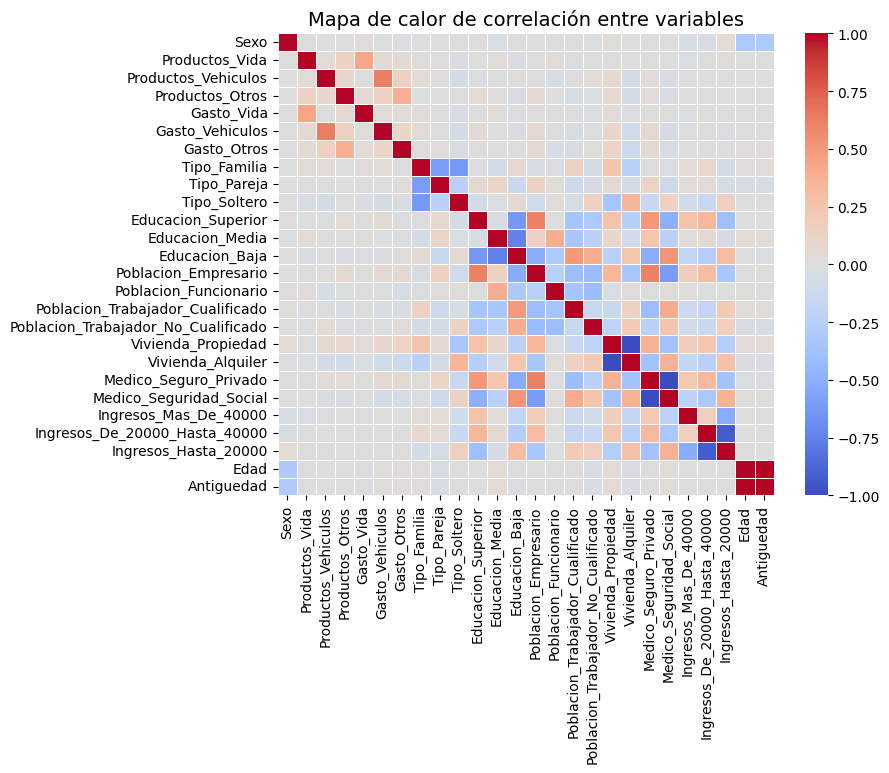

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Calculamos la matriz de correlación
matriz_corr = variables.corr()

# Configuramos el tamaño de la figura
plt.figure(figsize=(8, 6))

# Generamos el mapa de calor
sns.heatmap(
    matriz_corr,
    cmap='coolwarm',      # paleta de color
    center=0,             # centrado en 0
    annot=False,          # sin mostrar valores numéricos dentro de cada celda
    linewidths=0.5
)

plt.title("Mapa de calor de correlación entre variables", fontsize=14)
plt.show()

**Interpretación del mapa de calor**

El mapa de calor revela distintos niveles de correlación entre las variables del dataset. Tal como era esperable, las variables proporcionales dentro de un mismo grupo —como los tipos de familia, nivel educativo, nivel de ingresos u ocupación— presentan **correlaciones negativas entre sí**, reflejando su naturaleza complementaria (cuando una aumenta, las demás disminuyen).  
Por otro lado, se observan **correlaciones positivas moderadas** entre variables conceptualmente relacionadas, por ejemplo, entre el número de productos contratados y el gasto asociado a dichos productos, o entre edad y antigüedad, lo que refuerza la coherencia interna de los datos.  

En general, la matriz no muestra correlaciones excesivamente altas entre grupos distintos, lo que sugiere una **estructura de variables relativamente equilibrada y sin redundancias severas**.  
Este diagnóstico sirve como punto de partida para el siguiente paso del análisis, enfocado en detectar posibles valores atípicos (outliers).  


**Identificación de outliers**

Para dar inicio a la identificación de outliers, el primer paso es ubicar cuáles son las variables numéricas más críticas en términos de dispersión extrema.

Dado que K-Means es altamente sensible a valores muy alejados (que alterarían la posición de sus centroides), nos enfocaremos en detectar outliers. Utilizaremos la definición estricta del Rango Intercuartílico (IQR) con un umbral de 1.5 X IQR para calcular el porcentaje de valores atípicos en cada columna.

Esto nos permitirá priorizar las variables con mayor concentración de estos valores extremos para su posterior análisis visual.

Se ha aplicado la detección de valores atípicos univariados utilizando la metodología basada en el rango intercuartílico (IQR), con un umbral de 1.5 X IQR. Este análisis se ha restringido exclusivamente a las 8 variables numéricas seleccionadas por su naturaleza independiente y potencial influencia individual:

- Productos contratados (`Productos_*`)

- Gasto por tipo de producto (`Gasto_*`)

- Variables derivadas del cliente (`Edad`, `Antiguedad`)

In [14]:
import numpy as np
import pandas as pd

# Variables relevantes para detección de outliers
variables_outlier_focus = variables[[
    'Productos_Vida', 'Productos_Vehiculos', 'Productos_Otros',
    'Gasto_Vida', 'Gasto_Vehiculos', 'Gasto_Otros',
    'Edad', 'Antiguedad'
]]

# Umbral clásico de detección de outliers
UMBRAL_IQR = 1.5

print(f"Porcentaje de Outliers (usando {UMBRAL_IQR} * IQR) por Variable:")
print("-" * 60)

# Diccionario para almacenar resultados
outlier_summary_leve = {}

# Iterar por cada variable
for col in variables_outlier_focus.columns:
    Q1 = variables_outlier_focus[col].quantile(0.25)
    Q3 = variables_outlier_focus[col].quantile(0.75)
    IQR = Q3 - Q1

    # Límites de outliers
    lower_bound = Q1 - UMBRAL_IQR * IQR
    upper_bound = Q3 + UMBRAL_IQR * IQR

    # Contar outliers
    outliers_count = (
        (variables_outlier_focus[col] < lower_bound) |
        (variables_outlier_focus[col] > upper_bound)
    ).sum()

    # Calcular porcentaje
    outlier_percentage = (outliers_count / variables_outlier_focus.shape[0]) * 100
    outlier_summary_leve[col] = outlier_percentage

# Mostrar resultados ordenados
summary_df_leve = pd.DataFrame(
    outlier_summary_leve.items(),
    columns=['Variable', 'Porcentaje_Outliers_1_5_IQR']
).sort_values(by='Porcentaje_Outliers_1_5_IQR', ascending=False)

print(summary_df_leve)

# Mostrar solo variables con outliers
print("\nVariables con Outliers (Porcentaje > 0):")
print(summary_df_leve[summary_df_leve['Porcentaje_Outliers_1_5_IQR'] > 0])

Porcentaje de Outliers (usando 1.5 * IQR) por Variable:
------------------------------------------------------------
              Variable  Porcentaje_Outliers_1_5_IQR
0       Productos_Vida                     5.637171
3           Gasto_Vida                     5.637171
5          Gasto_Otros                     5.022207
1  Productos_Vehiculos                     2.801503
4      Gasto_Vehiculos                     1.571575
2      Productos_Otros                     0.102494
6                 Edad                     0.000000
7           Antiguedad                     0.000000

Variables con Outliers (Porcentaje > 0):
              Variable  Porcentaje_Outliers_1_5_IQR
0       Productos_Vida                     5.637171
3           Gasto_Vida                     5.637171
5          Gasto_Otros                     5.022207
1  Productos_Vehiculos                     2.801503
4      Gasto_Vehiculos                     1.571575
2      Productos_Otros                     0.102494


Los resultados revelan una presencia significativa de outliers en varias de estas variables:

`Productos_Vida` y `Gasto_Vida` presentan un 5,64% de valores atípicos, reflejando probablemente a clientes con múltiples productos contratados o con un gasto significativamente superior al promedio.

`Gasto_Otros` también muestra una proporción notable de outliers (5,02%), lo cual podría deberse a concentraciones puntuales de gasto alto en productos complementarios.

Las variables `Productos_Vehiculos` y `Gasto_Vehiculos` presentan niveles más moderados de atipicidad (2,8% y 1,57% respectivamente).

En contraste, `Productos_Otros` muestra una incidencia mínima de outliers (0,1%), y tanto `Edad` como `Antiguedad` no presentan valores fuera de los rangos típicos.


**Tratamiento de outliers**

El algoritmo K-Means es altamente sensible a los valores extremos (*outliers*), ya que estos **distorsionan la posición de los centroides** y, por ende, la forma final de los clústeres. Dado que hemos confirmado que las variables más críticas (Ingresos, Gasto, Productos) son **porcentajes de población de zona altamente sesgados**, los valores extremos son **segmentos de clientes válidos** (ej., clientes en zonas *premium*) y no errores de registro.

Siguiendo el enfoque propuesto, la mejor manera de manejar esta situación es **aislar** a estos clientes extremos. Esto permite:

1.  **Proteger los Centroides:** El *clustering* principal se entrenará con el grueso de los datos, obteniendo centroides más estables y representativos.
2.  **Crear un Segmento de Nicho:** Los clientes aislados formarán un clúster especial cuya interpretación de negocio debería ser altamente relevante

In [15]:
# Reutilizamos el subconjunto relevante
variables_outlier_focus = variables[[
    'Productos_Vida', 'Productos_Vehiculos', 'Productos_Otros',
    'Gasto_Vida', 'Gasto_Vehiculos', 'Gasto_Otros',
    'Edad', 'Antiguedad'
]]

# Inicializar contador de outliers por cliente
outlier_count = pd.Series(0, index=variables_outlier_focus.index)

# Definir umbral para detección univariada
UMBRAL_IQR = 1.5

# Contar cuántas variables son outlier por cliente
for col in variables_outlier_focus.columns:
    Q1 = variables_outlier_focus[col].quantile(0.25)
    Q3 = variables_outlier_focus[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - UMBRAL_IQR * IQR
    upper = Q3 + UMBRAL_IQR * IQR
    es_outlier = (variables_outlier_focus[col] < lower) | (variables_outlier_focus[col] > upper)
    outlier_count += es_outlier.astype(int)

# Aislar clientes multivariadamente atípicos
UMBRAL_MULTIVARIADO = 2
clientes_outliers = variables[outlier_count >= UMBRAL_MULTIVARIADO].copy()
clientes_normales = variables[outlier_count < UMBRAL_MULTIVARIADO].copy()

# Resumen
print("Clientes identificados como multivariadamente outliers:", clientes_outliers.shape[0])
print("Clientes restantes para clustering principal:", clientes_normales.shape[0])

Clientes identificados como multivariadamente outliers: 203
Clientes restantes para clustering principal: 2724


**Outliers mutivariados**

Tras la identificación de outliers univariados, se procedió a detectar clientes con **comportamientos extremos en múltiples dimensiones relevantes simultáneamente** (productos contratados, gasto, edad y antigüedad).

Inicialmente, se consideró como multivariado atípico a aquel cliente que presentaba valores extremos en 3 o más variables, lo que resultó en apenas 19 clientes detectados, una proporción demasiado baja para representar un grupo distintivo.

Con el objetivo de obtener un grupo más representativo y consistente con el propósito del clustering, **se decidió reducir el umbral a 2 o más variables con valores atípicos**. Esta estrategia permitió identificar:

**203 clientes multivariadamente atípicos**, equivalentes a aproximadamente el 7,3% del total.

Este conjunto ha sido segregado del dataset principal, con la intención de formar eventualmente un clúster específico. De esta forma, se evita que estos valores extremos distorsionen la formación de centroides en los grupos más comunes.

El resto del conjunto de datos, ya sin estos casos extremos, queda preparado para continuar con el proceso de transformación y escalado previo al modelado.

## **FASE 6: Transformación / Escalado de variables**

Con el objetivo de tomar decisiones fundamentadas respecto a la transformación y selección de variables, se realizó una exploración visual mediante histogramas para cada una de las 26 variables. Esto permitió observar su distribución empírica, detectar asimetrías, presencia de valores extremos y posibles relaciones entre grupos de variables.

A partir de este análisis exploratorio, se definieron las transformaciones necesarias, los casos donde era suficiente aplicar escalado estándar, y las variables redundantes que debían excluirse para evitar colinealidad o sobrerrepresentación en el modelo de clustering.

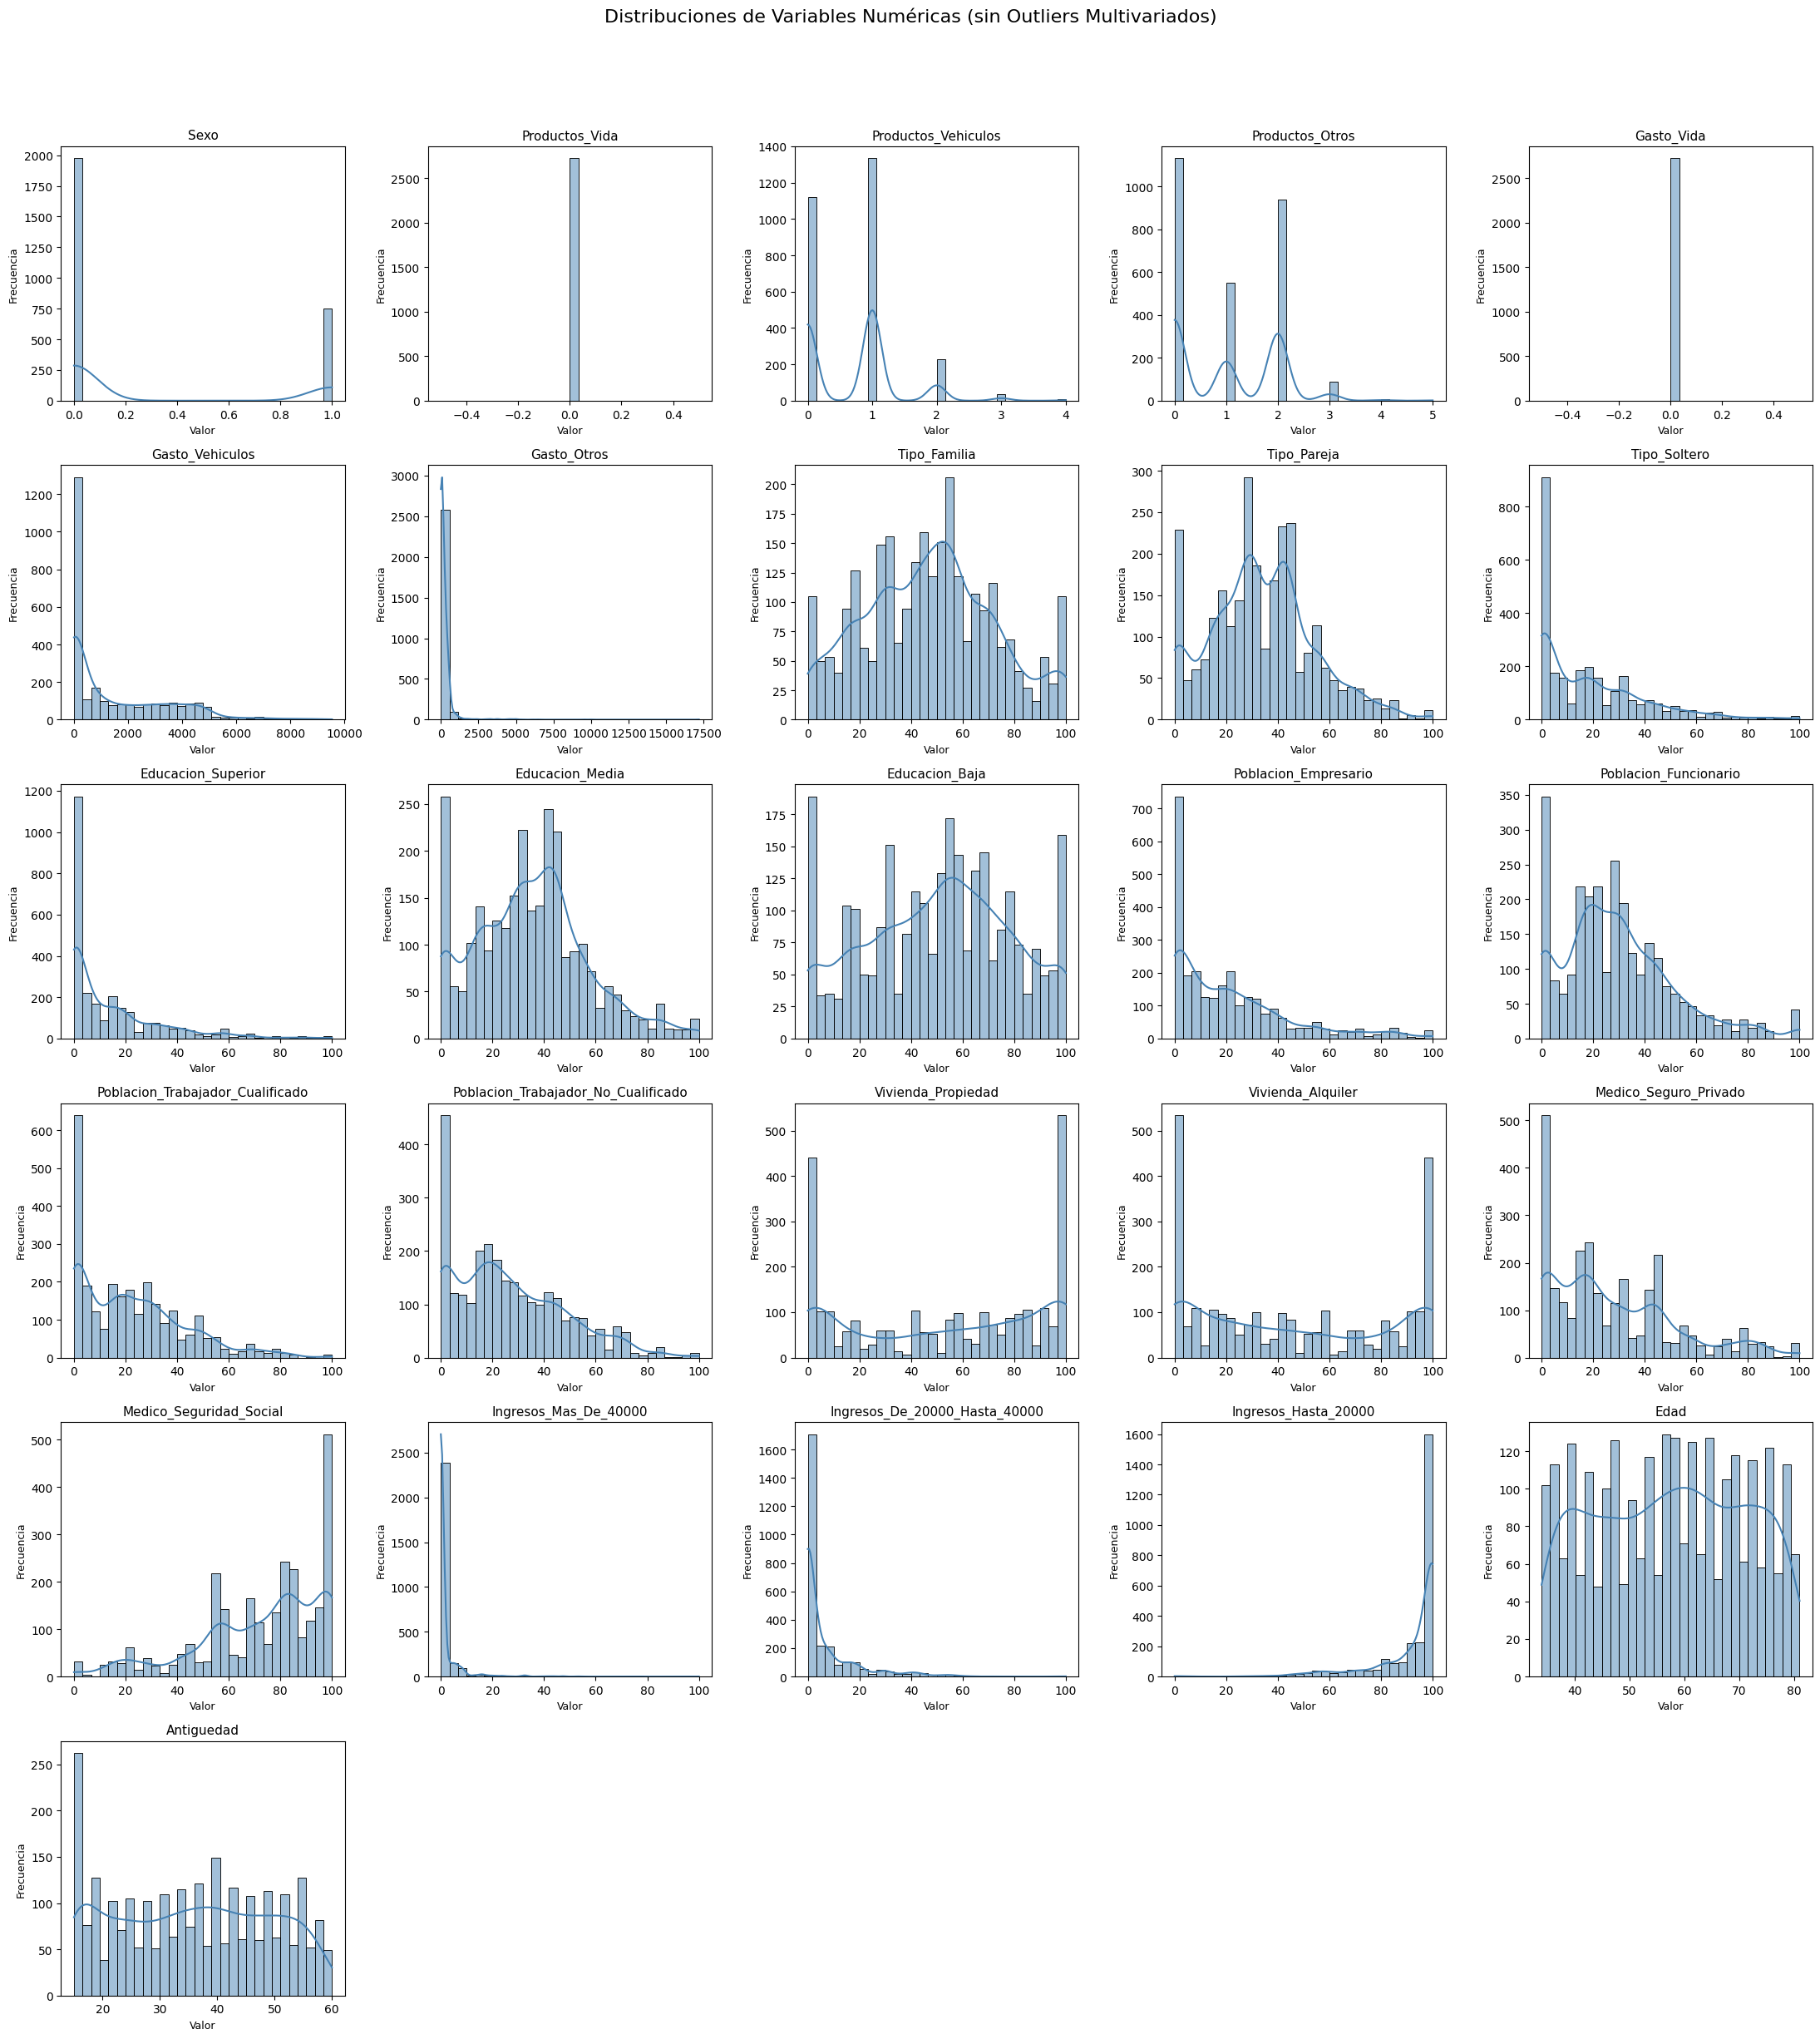

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dataset base para visualización
df_visual_pre = clientes_normales.select_dtypes(include=np.number)

# Columnas numéricas y cantidad
numerical_cols = df_visual_pre.columns
num_vars = len(numerical_cols)

# Configuración del grid
ncols = 5
nrows = int(np.ceil(num_vars / ncols))

# Crear los histogramas
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df_visual_pre[col], ax=axes[i], kde=True, bins=30, color='steelblue')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('Valor', fontsize=9)
    axes[i].set_ylabel('Frecuencia', fontsize=9)

# Eliminar subplots vacíos
for j in range(num_vars, nrows * ncols):
    fig.delaxes(axes[j])

plt.suptitle('Distribuciones de Variables Numéricas (sin Outliers Multivariados)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

**Eliminación de Variables Redundantes por Colinealidad Perfecta**

El conjunto de datos contiene varios grupos de variables proporcionales que describen categorías mutuamente excluyentes dentro de una misma dimensión. Estas variables, por diseño, suman siempre 100% dentro de su grupo, lo cual implica una colinealidad lineal perfecta. Esta característica es problemática para algoritmos como K-Means, que utilizan distancias euclídeas y requieren independencia entre variables para producir clústeres significativos y estables.

Por ejemplo:

El grupo de ingresos (`Ingresos_*`) representa la distribución porcentual de los niveles de ingresos en la zona.

El grupo de tipo de familia (`Tipo_*`) representa la distribución de formas de convivencia en el hogar.

Lo mismo ocurre con `Educación_*`, `Poblacion_*` , `Vivienda_*` y `Medico_*`.

Mantener todas las variables de estos grupos introduciría redundancia matemática y distorsionaría las distancias entre clientes, ya que una variación en una de las variables está automáticamente compensada por las otras del mismo grupo.

**Criterio para la Eliminación dentro de Cada Grupo**

En principio, cualquier variable podría haber sido eliminada de forma válida dentro de cada grupo, ya que la información que aporta es completamente determinada por las otras variables. Sin embargo, se optó por un criterio práctico adicional para decidir cuál eliminar:

Se eliminó la variable que presentaba el mayor porcentaje de valores atípicos (outliers univariados) dentro de su grupo.

Este criterio ofrece una ventaja adicional: al eliminar la variable más propensa a valores extremos, se reduce el ruido estadístico en el modelo sin sacrificar capacidad informativa.

In [17]:
# Lista de variables a eliminar (una por grupo proporcional colineal)
variables_colineales_a_eliminar = [
    'Ingresos_Mas_De_40000',
    'Educacion_Superior',
    'Poblacion_Empresario',
    'Tipo_Soltero',
    'Medico_Seguridad_Social',
    'Vivienda_Alquiler'
]

# Eliminarlas del conjunto limpio
clientes_normales_reducido = clientes_normales.drop(columns=variables_colineales_a_eliminar)

# Verificar resultado
print("Dimensiones del dataset tras eliminar variables redundantes:", clientes_normales_reducido.shape)
clientes_normales_reducido.head()

Dimensiones del dataset tras eliminar variables redundantes: (2724, 20)


,Sexo,Productos_Vida,Productos_Vehiculos,Productos_Otros,Gasto_Vida,Gasto_Vehiculos,Gasto_Otros,Tipo_Familia,Tipo_Pareja,Educacion_Media,Educacion_Baja,Poblacion_Funcionario,Poblacion_Trabajador_Cualificado,Poblacion_Trabajador_No_Cualificado,Vivienda_Propiedad,Medico_Seguro_Privado,Ingresos_De_20000_Hasta_40000,Ingresos_Hasta_20000,Edad,Antiguedad
0,1,0,1,0,0.0,617.55,0.00,75.10,18.27,39.20,58.05,28.17,21.01,27.13,71.34,32.77,1.47,96.30,56,35
2,0,0,1,2,0.0,3572.01,273.15,46.41,30.94,28.36,64.01,18.30,34.78,41.43,56.37,17.48,1.72,98.28,74,52
4,0,0,1,0,0.0,4289.61,0.00,37.63,29.59,52.61,20.40,53.30,1.92,12.61,12.63,45.32,27.01,51.66,69,48
5,0,0,0,1,0.0,0.00,80.27,28.89,37.14,41.90,53.42,26.95,3.08,62.51,65.12,4.89,6.87,93.12,67,43
6,1,0,0,0,0.0,0.00,0.00,16.23,25.34,13.30,85.42,29.04,25.28,42.70,7.68,8.49,0.00,100.00,62,39


**Fase de Transformación y Escalado de Variables**

Una vez eliminadas las variables colineales, el dataset final consta exclusivamente de 20 variables numéricas. Antes de aplicar algoritmos de clustering como **K-Means**, es fundamental preparar estas variables para asegurar una representación adecuada en el espacio de distancias. En esta fase, se aplicarán tres tipos de acciones:

- **Transformación logarítmica** para reducir la asimetría positiva pronunciada.
- **Escalado estándar (z-score)** para normalizar la magnitud de todas las variables.
- **Sin transformación ni escalado** para variables ya adecuadamente representadas (como binarias).

**Criterio por Variable**

| Variable                            | Tipo                         | Acción Aplicada                           |
|-------------------------------------|------------------------------|--------------------------------------------|
| `Sexo`                              | Binaria (0/1)                |  Sin transformación ni escalado          |
| `Edad`                              | Numérica (años)              |  Escalado (StandardScaler)               |
| `Antiguedad`                        | Numérica (años)              |  Escalado (StandardScaler)               |
| `Productos_Vida`                    | Discreta (enteros, muchos 0) |  Log1p + Escalado                         |
| `Productos_Vehiculos`               | Discreta (enteros, muchos 0) |  Log1p + Escalado                         |
| `Productos_Otros`                   | Discreta (enteros, muchos 0) |  Log1p + Escalado                         |
| `Gasto_Vida`                        | Continua, muchos ceros       |  Log1p + Escalado                         |
| `Gasto_Vehiculos`                   | Continua, muchos ceros       |  Log1p + Escalado                         |
| `Gasto_Otros`                       | Continua, muchos ceros       |  Log1p + Escalado                         |
| `Tipo_Familia`                      | Proporcional                 |  Escalado (StandardScaler)               |
| `Tipo_Pareja`                       | Proporcional                 |  Escalado (StandardScaler)               |
| `Educacion_Media`                   | Proporcional                 |  Escalado (StandardScaler)               |
| `Educacion_Baja`                    | Proporcional                 |  Escalado (StandardScaler)               |
| `Poblacion_Funcionario`             | Proporcional                 |  Escalado (StandardScaler)               |
| `Poblacion_Trabajador_Cualificado` | Proporcional                 |  Escalado (StandardScaler)               |
| `Poblacion_Trabajador_No_Cualificado` | Proporcional              |  Escalado (StandardScaler)               |
| `Vivienda_Propiedad`                | Proporcional                 |  Escalado (StandardScaler)               |
| `Medico_Seguro_Privado`            | Proporcional                 |  Escalado (StandardScaler)               |
| `Ingresos_De_20000_Hasta_40000`    | Proporcional                 |  Escalado (StandardScaler)               |
| `Ingresos_Hasta_20000`             | Proporcional                 |  Escalado (StandardScaler)               |

---

Esta estrategia asegura que:
- Las variables con fuerte asimetría sean suavizadas con transformaciones logarítmicas.
- Todas las variables (excepto la binaria `Sexo`) tengan media 0 y desviación estándar 1, garantizando una distancia euclídea equilibrada entre observaciones durante el clustering.


In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Creamos una copia del dataset original reducido
clientes_transformado = clientes_normales_reducido.copy()

# 🔹 Variables que se transformarán con log1p (asimetría y ceros frecuentes)
log_transform_vars = [
    'Productos_Vida', 'Productos_Vehiculos', 'Productos_Otros',
    'Gasto_Vida', 'Gasto_Vehiculos', 'Gasto_Otros'
]

# Aplicar log1p (log(x + 1)) a las variables seleccionadas
for col in log_transform_vars:
    clientes_transformado[col] = np.log1p(clientes_transformado[col])

# 🔹 Variables a escalar con StandardScaler
# (Excluimos 'Sexo' porque ya está codificada entre 0 y 1)
vars_to_scale = clientes_transformado.columns.drop('Sexo')

# Aplicar escalado
scaler = StandardScaler()
clientes_transformado[vars_to_scale] = scaler.fit_transform(clientes_transformado[vars_to_scale])

Tras la transformación logarítmica de las variables con fuerte asimetría (como los gastos y número de productos contratados) y el escalado estándar de las variables restantes, procedemos a visualizar nuevamente la distribución de todas las variables numéricas del dataset.

Este paso nos permite verificar gráficamente cómo han cambiado las distribuciones respecto al estado original (sin transformaciones) y evaluar si las variables se encuentran ahora en una escala homogénea y con menos sesgo, lo cual es crucial para garantizar el buen desempeño del algoritmo de clustering K-Means que se aplicará en fases posteriores.

A continuación se muestran los histogramas de todas las variables tras el preprocesamiento.

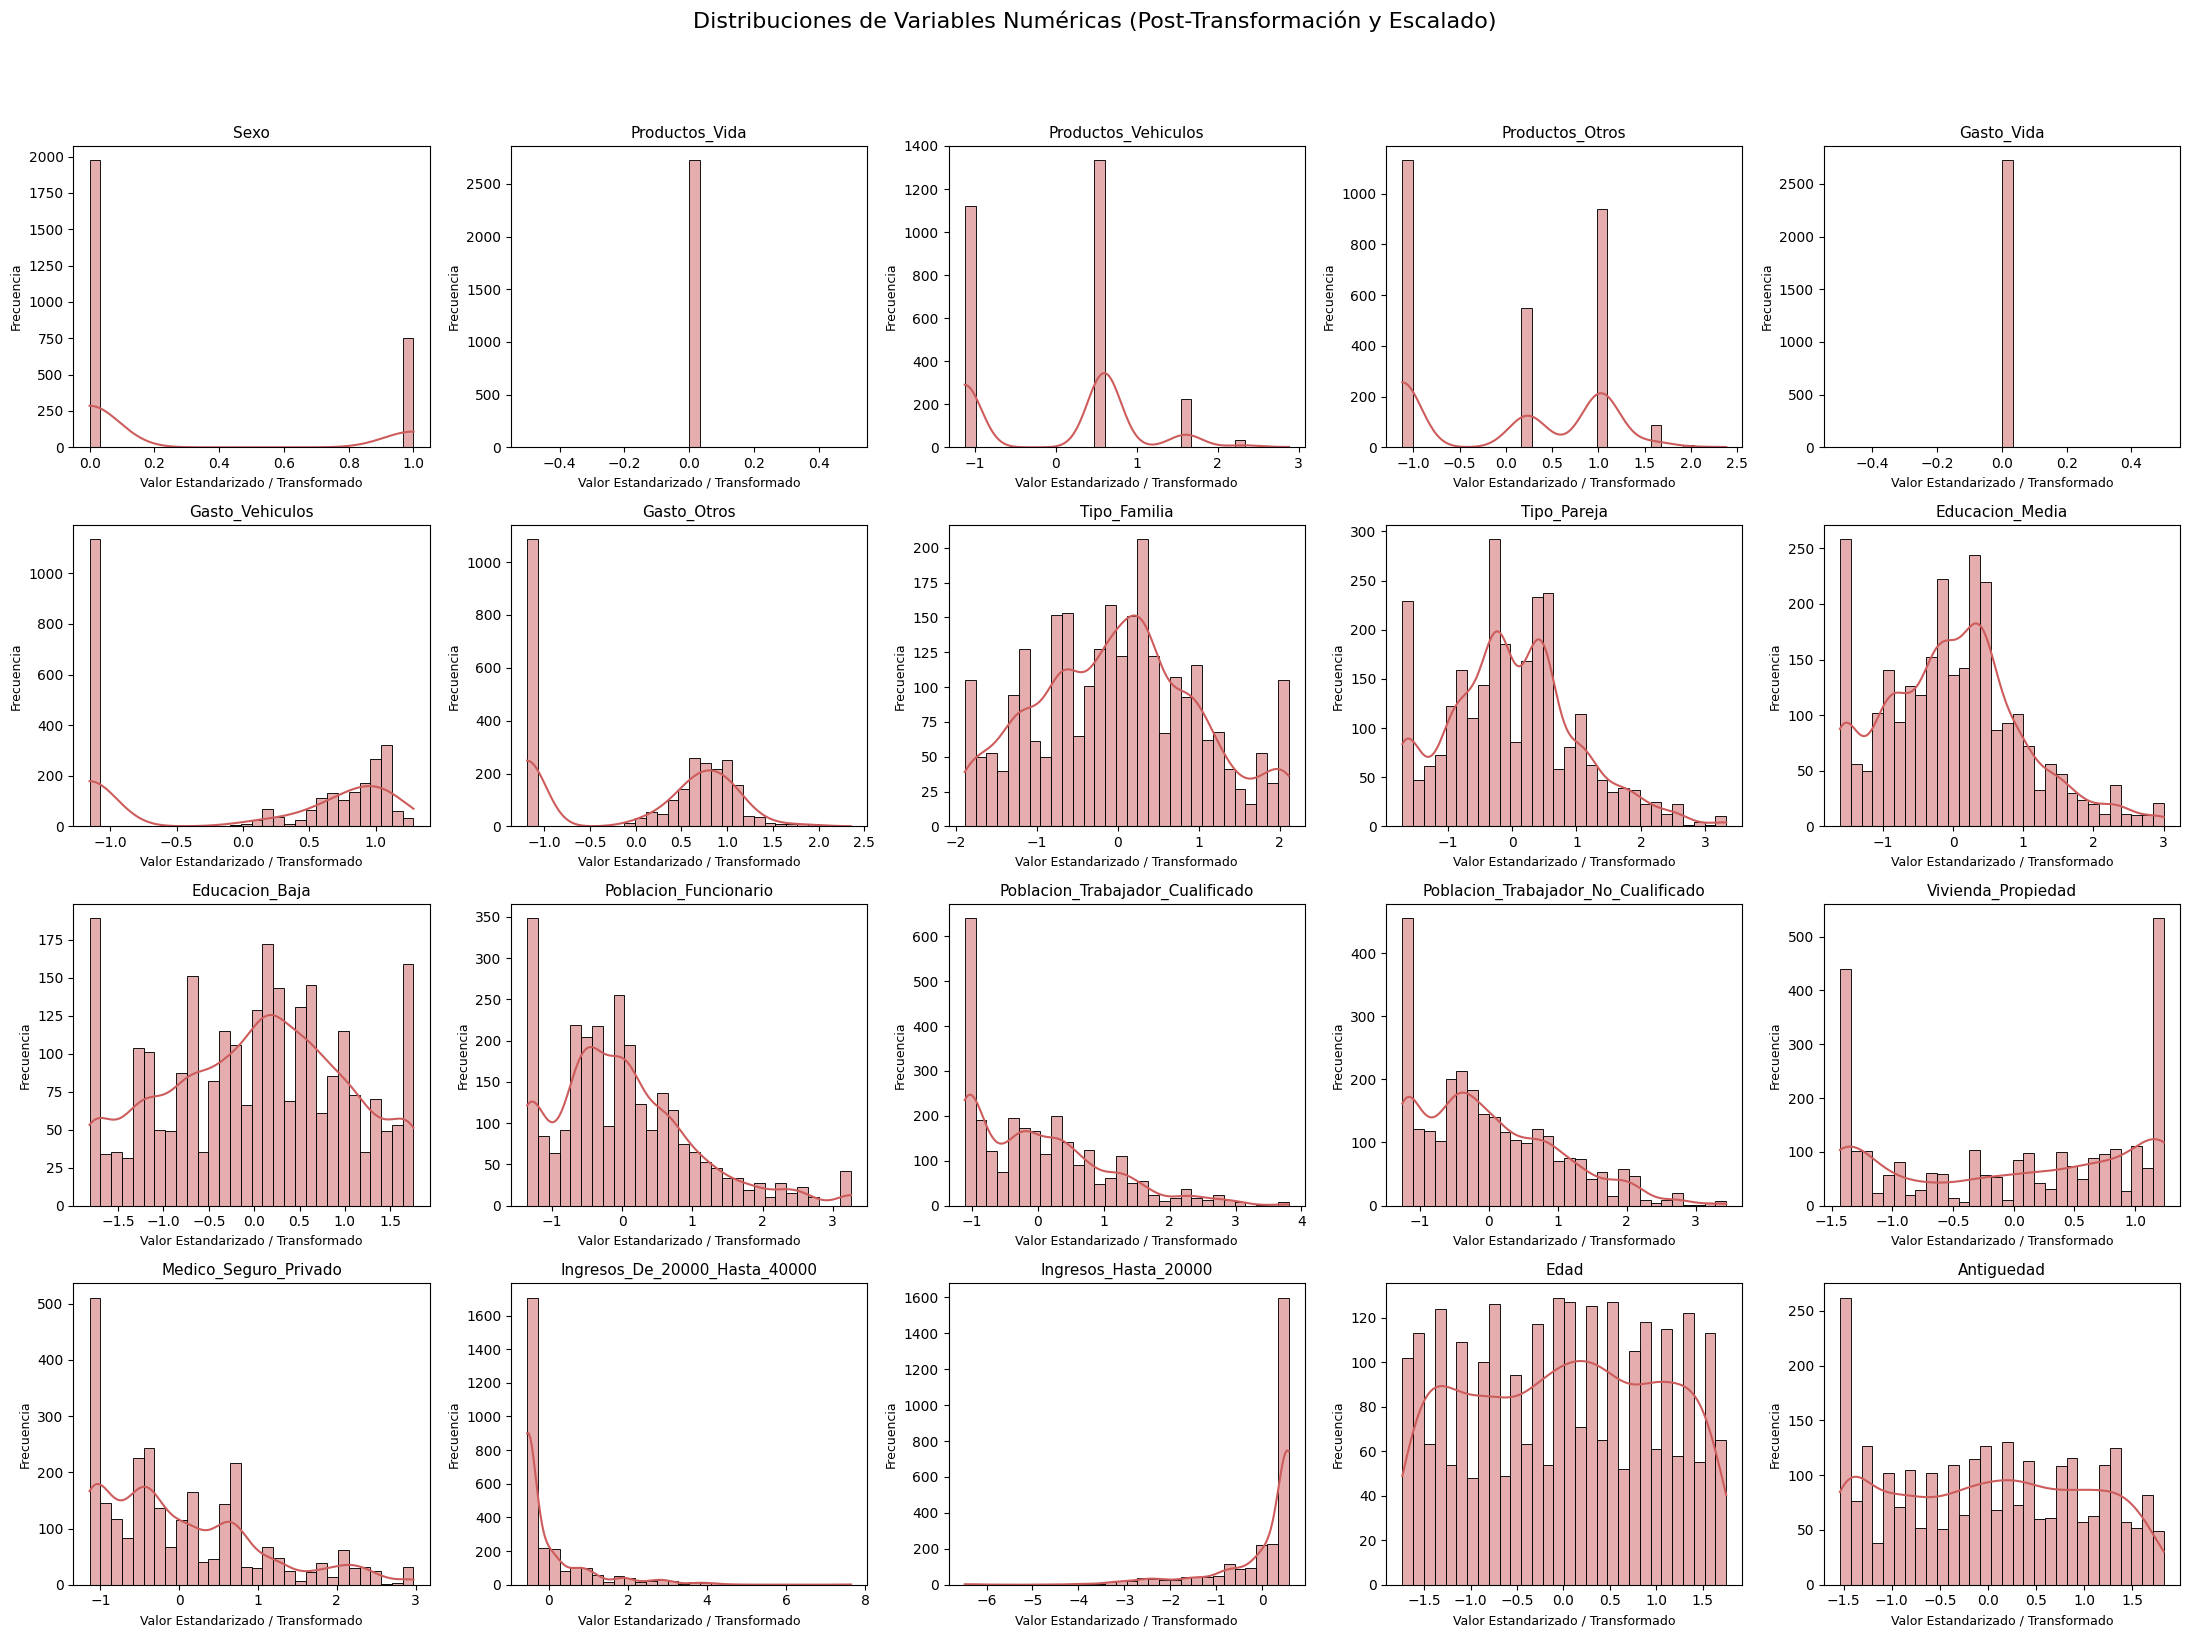

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dataset post-transformación para visualización
df_visual_post = clientes_transformado.select_dtypes(include=np.number)

# Columnas numéricas y cantidad
numerical_cols_post = df_visual_post.columns
num_vars_post = len(numerical_cols_post)

# Configuración del grid
ncols = 5
nrows = int(np.ceil(num_vars_post / ncols))

# Crear los histogramas
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_post):
    sns.histplot(df_visual_post[col], ax=axes[i], kde=True, bins=30, color='indianred')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('Valor Estandarizado / Transformado', fontsize=9)
    axes[i].set_ylabel('Frecuencia', fontsize=9)

# Eliminar subplots vacíos
for j in range(num_vars_post, nrows * ncols):
    fig.delaxes(axes[j])

plt.suptitle('Distribuciones de Variables Numéricas (Post-Transformación y Escalado)', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Una vez aplicadas las transformaciones logarítmicas y la estandarización a las variables seleccionadas, se procedió a representar gráficamente todas las distribuciones resultantes mediante histogramas.

Este paso ha permitido comprobar visualmente que:

- Las variables con alta asimetría positiva (como los gastos y número de productos) muestran ahora distribuciones más suavizadas y manejables.

- Las variables proporcionales (educación, vivienda, ingresos, etc.) presentan una dispersión más centrada, tras su estandarización.

- Variables como Edad y Antigüedad, previamente derivadas de fechas, también han sido correctamente estandarizadas.

- La variable Sexo, al haber sido codificada binariamente, mantiene su naturaleza discreta, como es esperable.

En conjunto, este procesamiento ha asegurado que todas las variables del dataset estén ahora en una escala comparable, lo cual es un requisito fundamental para aplicar posteriormente técnicas de clustering como K-Means, donde las distancias euclidianas son sensibles a las escalas y distribuciones de las variables.

Esta fase culmina así con un conjunto de datos completamente numérico, transformado y estandarizado, listo para la siguiente etapa del análisis.

## **FASE 7: Reducción de dimensionalidad**

En esta fase se evaluó la posibilidad de aplicar técnicas de reducción de dimensionalidad, como **PCA (Análisis de Componentes Principales)**, con el objetivo de simplificar la estructura del dataset previo al clustering.

Sin embargo, tras el análisis realizado se ha decidido **NO aplicar reducción de dimensionalidad**, por las siguientes razones:

- **Interpretabilidad**: Uno de los objetivos clave del proyecto es poder **interpretar y describir los clusters finales** en función de variables significativas como el nivel de gasto, edad, tipo de unidad familiar o nivel educativo. El uso de PCA dificultaría esta interpretación, ya que las componentes principales son combinaciones abstractas de múltiples variables originales.

- **Número de variables manejable**: Tras la eliminación de variables redundantes y la transformación adecuada de los datos, el dataset contiene un número razonable de variables numéricas (20), lo cual no representa una carga computacional significativa ni justifica la pérdida de interpretabilidad.

- **Preparación adecuada del dataset**: Las variables han sido cuidadosamente normalizadas, transformadas y seleccionadas, minimizando problemas como la colinealidad y la presencia de outliers. Esto hace que el espacio de representación ya sea adecuado para aplicar clustering directamente.

**Nota:** Se considera la posibilidad de utilizar PCA a posteriori, únicamente **si la implementación posterior de K-Means no produce resultados satisfactorios**, revaluando el uso de técnicas de reducción de dimensionalidad como parte del pipeline de clustering.

## **FASE 8: Selección del K Óptimo**

Antes de aplicar el algoritmo de clustering K-Means, es fundamental determinar cuántos grupos (clusters) deberían formarse para segmentar adecuadamente a los clientes. Para ello, se emplean dos enfoques complementarios:

**Método del Codo**

Este método evalúa la **inercia** (suma de las distancias cuadradas dentro de cada cluster) para distintos valores de \(k\). A medida que aumentamos el número de clusters, la inercia disminuye, pero llega un punto en el que las mejoras se vuelven marginales. Ese punto de inflexión se conoce como “el codo” y sugiere un número óptimo de clusters.

**Coeficiente de Silhouette**

El coeficiente de silhouette mide qué tan similar es un cliente con los miembros de su propio cluster en comparación con los de otros clusters. Toma valores entre -1 y 1, donde valores más cercanos a 1 indican una mejor separación entre grupos. Este análisis permite identificar el valor de \(k\) que proporciona la mejor cohesión y separación.

A continuación, se presentan ambos análisis para ayudar a determinar el valor óptimo de \(k\) en este problema de segmentación.

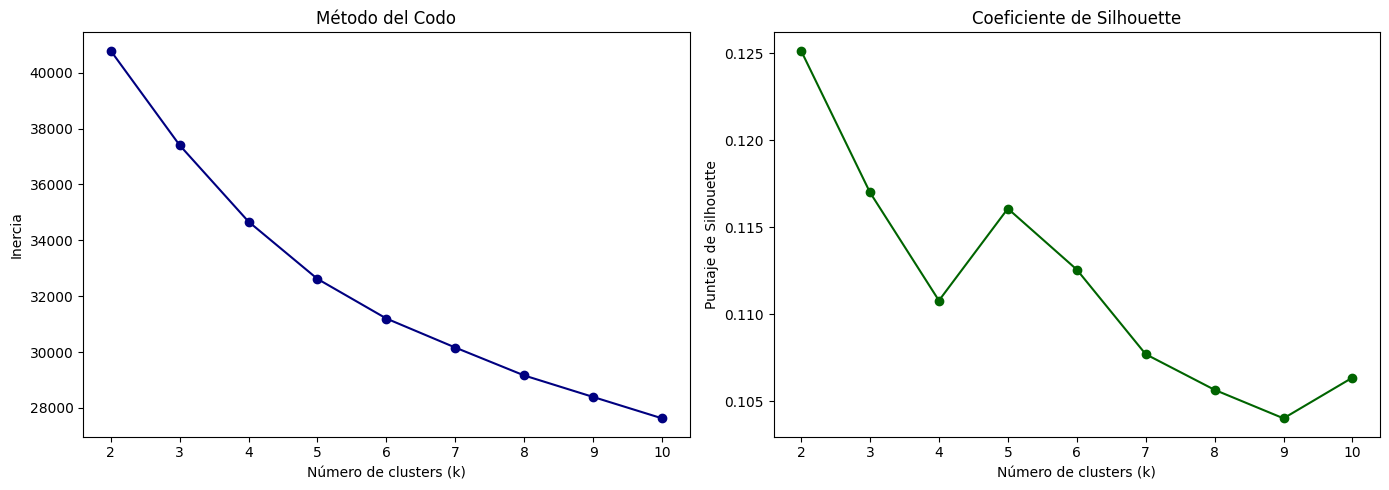

In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Rango de K a probar
k_range = range(2, 11)

# Listas para guardar resultados
inertias = []
silhouette_scores = []

# Aplicar K-Means para cada valor de K
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clientes_transformado)

    # Inercia para el método del codo
    inertias.append(kmeans.inertia_)

    # Coeficiente de silhouette
    score = silhouette_score(clientes_transformado, kmeans.labels_)
    silhouette_scores.append(score)

# Visualización de los resultados
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico del Método del Codo
ax[0].plot(k_range, inertias, marker='o', color='navy')
ax[0].set_title('Método del Codo')
ax[0].set_xlabel('Número de clusters (k)')
ax[0].set_ylabel('Inercia')

# Gráfico del Coeficiente de Silhouette
ax[1].plot(k_range, silhouette_scores, marker='o', color='darkgreen')
ax[1].set_title('Coeficiente de Silhouette')
ax[1].set_xlabel('Número de clusters (k)')
ax[1].set_ylabel('Puntaje de Silhouette')

plt.tight_layout()
plt.show()

**Análisis del Número Óptimo de Clusters**

El gráfico de la izquierda muestra cómo disminuye la inercia (variabilidad intra-cluster) al aumentar el número de clusters. Aunque la curva desciende de forma continua, se observa un **posible "codo" alrededor de \(k = 5\)**. A partir de ese punto, las reducciones adicionales en la inercia son cada vez menos significativas, lo cual sugiere que agregar más clusters aporta beneficios marginales.

El gráfico de la derecha indica que el **puntaje más alto de silhouette se obtiene para \(k = 2\)**, lo cual sugiere una buena cohesión y separación entre clusters. Sin embargo, valores como \(k = 5\) también presentan un silhouette razonablemente alto, y permiten una segmentación más rica del conjunto de clientes.

**Recomendación**

Aunque \(k = 2\) ofrece simplicidad y un valor óptimo de silhouette, **\(k = 5\)** representa un **buen equilibrio entre calidad del clustering y granularidad útil para la segmentación**. Dado que este análisis tiene como objetivo identificar grupos diferenciados de clientes, **se propone continuar con \(k = 5\)** como valor inicial, sujeto a ajustes tras la interpretación de los resultados.


## **FASE 9: Aplicación de K-Means**

Una vez determinado el número óptimo de clusters mediante el método del codo y el coeficiente de Silhouette, se procede a aplicar el algoritmo K-Means utilizando \( k = 5 \), que ha demostrado ser un buen equilibrio entre compactación y separación de los grupos.

K-Means es un algoritmo de partición que agrupa observaciones basándose en su similitud (medida usualmente por la distancia euclidiana), minimizando la varianza intra-cluster. Es especialmente sensible a la escala de los datos, razón por la cual previamente se han aplicado transformaciones logarítmicas y escalado estándar a las variables seleccionadas.

El objetivo de esta fase es obtener una etiqueta de cluster para cada cliente en el conjunto de datos, lo que permitirá posteriormente interpretar los perfiles resultantes y evaluar su coherencia con la variable objetivo excluida anteriormente.

In [21]:
from sklearn.cluster import KMeans

# Aplicar K-Means con k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
clientes_transformado['Cluster'] = kmeans_final.fit_predict(clientes_transformado)

# Mostrar número de clientes por cluster
clientes_transformado['Cluster'].value_counts().sort_index()

,count
Cluster,
0,557
1,347
2,586
3,678
4,556


Tras aplicar el algoritmo K-Means con \( k = 5 \), se ha obtenido una segmentación relativamente equilibrada entre los diferentes grupos de clientes. La distribución de registros por cluster es la siguiente:

- **Cluster 0:** 557 clientes  
- **Cluster 1:** 347 clientes  
- **Cluster 2:** 586 clientes  
- **Cluster 3:** 678 clientes  
- **Cluster 4:** 556 clientes  

Esta distribución sugiere que no hay un desbalance excesivo entre clusters, lo cual es positivo para el análisis posterior. Cada grupo contiene una muestra suficientemente representativa de clientes, lo que permitirá interpretar patrones de comportamiento o características comunes en las siguientes fases del proyecto.

Además de estos cinco grupos:
- **Cluster extra:** 203 clientes *(outliers multivariados)*

Este grupo fue segregado antes del modelado principal para evitar que valores extremos distorsionaran los centroides de los clústeres.

En conjunto, este enfoque permite preservar tanto la estabilidad de los clústeres principales como la interpretación específica de clientes con características anómalas que podrían constituir un segmento aparte.

## **FASE 10: Evaluación e interpretación**

En esta fase se busca explorar la relevancia comercial de los clústeres obtenidos aplicando K-Means. Para ello, se reincorpora al análisis la variable objetivo original: `Seguro_Vivienda`, que indica si el cliente contrató el seguro (1) o no (0).

El objetivo es identificar si algunos segmentos presentan una **mayor propensión a contratar el seguro**, lo que permitiría priorizar esfuerzos comerciales o diseñar estrategias de marketing más personalizadas.

Se calcularán:

- La cantidad de clientes que contrataron el seguro por clúster.
- La **tasa de conversión parcial** por clúster (porcentaje de contrataciones dentro del clúster).
- La **tasa de conversión global** del dataset.

In [22]:
# Añadir la variable objetivo al DataFrame
clientes_transformado['Seguro_Vivienda'] = targets

# Agrupar por clúster y calcular métricas
resumen_clusters = clientes_transformado.groupby('Cluster').agg(
    Total_Clientes=('Seguro_Vivienda', 'count'),
    Contratos_Seguro=('Seguro_Vivienda', 'sum'),
    Tasa_Conversion=('Seguro_Vivienda', 'mean')
).reset_index()

# Ordenar los resultados por tasa de conversión descendente
resumen_clusters.sort_values(by='Tasa_Conversion', ascending=False, inplace=True)

# Mostrar la tabla resumen
print("Resumen por Clúster (con Variable Objetivo):")
print(resumen_clusters)

# Calcular el total de clientes que contrataron el seguro
total_si = targets.sum()
print("\nClientes que contrataron el seguro:", total_si)

# Calcular la tasa de conversión global
tasa_global = total_si / len(targets)
print("Tasa de conversión global:", round(tasa_global * 100, 2), "%")

Resumen por Clúster (con Variable Objetivo):
   Cluster  Total_Clientes  Contratos_Seguro  Tasa_Conversion
0        0             557                50         0.089767
4        4             556                44         0.079137
1        1             347                26         0.074928
3        3             678                21         0.030973
2        2             586                 3         0.005119

Clientes que contrataron el seguro: 165
Tasa de conversión global: 5.64 %


Los resultados muestran diferencias significativas en las tasas de conversión entre los distintos clústeres. Por ejemplo:

- El clúster con la mayor tasa de conversión (≈ 9%) duplica la tasa global del dataset (5.64%).
- En contraste, el clúster con menor tasa de conversión tiene apenas un 0.5%, lo que sugiere un perfil de clientes considerablemente menos propensos a contratar el seguro.

Esto confirma que los clústeres obtenidos no solo reflejan diferencias estructurales en los perfiles de los clientes, sino que también se traducen en **diferencias en el comportamiento comercial** (en este caso, la contratación del seguro).

Por tanto, estos segmentos podrían utilizarse como base para estrategias como:

- **Campañas dirigidas** a los clústeres con alta probabilidad de conversión.
- **Campañas de retención o activación** sobre clústeres con baja tasa, si existe interés en transformarlos.
- **Análisis de características dominantes** en clústeres con mejor desempeño, para extrapolar aprendizajes al resto.

**Análisis de Características Definitorias por Clúster**

También es fundamental comprender qué distingue a cada grupo. Para ello, se ha calculado la **media estandarizada** (tras escalado) de cada variable dentro de cada clúster, lo que permite identificar **qué atributos están por encima o por debajo del promedio global** en cada grupo.

Este análisis permite:
- Identificar patrones de comportamiento o perfil sociodemográfico predominante.
- Evaluar qué variables están más asociadas a una mayor o menor propensión a contratar el seguro.
- Facilitar una interpretación estratégica de cada clúster, lo que será útil tanto para acciones comerciales como para validar la segmentación realizada.

A continuación se detalla el perfil medio de cada clúster, con especial énfasis en su comportamiento frente a la variable objetivo `Seguro_Vivienda`.

In [23]:
# Agrupar por clúster y calcular medias de todas las variables
caracteristicas_clusters = clientes_transformado.groupby('Cluster').mean(numeric_only=True)

# Transponer para visualizar como tabla: variables vs clústeres
caracteristicas_clusters.T

Cluster,0,1,2,3,4
Sexo,0.269300,0.213256,0.310580,0.280236,0.275180
Productos_Vida,0.000000,0.000000,0.000000,0.000000,0.000000
Productos_Vehiculos,0.863500,-0.044961,-1.116006,0.179811,0.119964
Productos_Otros,0.933037,0.003081,0.679258,-1.118184,-0.289005
Gasto_Vida,0.000000,0.000000,0.000000,0.000000,0.000000
Gasto_Vehiculos,0.888930,-0.032770,-1.144871,0.151339,0.152021
Gasto_Otros,0.888786,0.031361,0.744782,-1.142207,-0.302089
Tipo_Familia,0.140098,0.295077,-0.099976,0.073416,-0.308662
Tipo_Pareja,-0.167266,0.126605,-0.089348,-0.129785,0.340985
Educacion_Media,-0.348154,0.114930,-0.294608,-0.436457,1.119784


**Interpretación de Perfiles por Clúster**

A continuación, se ha realizado un análisis exhaustivo de las características promedio de cada clúster y su relación con la variable objetivo (contratación del seguro de vivienda). La tabla de medias estandarizadas permitió construir perfiles claros para cada segmento:

**Clúster 0 - Alta contratación y consumo**
- **Perfil de consumo elevado:** Contratación destacada de productos de vehículos y otros, acompañado de un gasto alto.
- **Perfil sociodemográfico:** Mayores niveles de educación baja y mayor proporción de trabajadores no cualificados.
- **Resultado:** Es el grupo con **mayor tasa de conversión** (~8.9%), lo que lo convierte en un objetivo prioritario para acciones comerciales.

**Clúster 1 - Zona estable con ingresos medios**
- **Ingresos medios y seguridad privada:** Alta proporción de hogares con ingresos intermedios, cobertura médica privada, y mayor propiedad de vivienda.
- **Menor presencia de educación baja:** Nivel educativo más equilibrado.
- **Resultado:** Segunda mejor tasa de conversión (~7.5%). Grupo atractivo por su estabilidad económica.

**Clúster 2 - Desvinculado del producto**
- **Consumo nulo:** No contratan productos ni generan gasto asociado.
- **Perfil de baja implicación:** Escasa conversión (~0.5%), el **grupo menos rentable comercialmente**.
- **Resultado:** Puede tratarse de zonas sin interés en seguros o con barreras estructurales.

**Clúster 3 - Mayoría vulnerable con bajo consumo**
- **Perfil modesto:** Bajo nivel educativo, predominancia de ocupaciones no cualificadas, y baja contratación de productos.
- **Resultado:** Tasa de conversión baja (~3%), aunque no nula. Segmento sensible, posiblemente con necesidades específicas mal cubiertas.

**Clúster 4 - Perfil profesional y educativo**
- **Nivel educativo alto:** Mayores valores en educación media/superior y alta proporción de funcionarios.
- **Consumo intermedio:** No destacan en contratación, pero tampoco están desvinculados.
- **Resultado:** Buena tasa de conversión (~7.9%), lo que lo hace interesante por su capacidad de respuesta pese a bajo consumo.

**Clúster extra - Outliers**

Durante el preprocesamiento se identificaron **203 clientes como outliers multivariados**, cuya combinación de valores extremos podría distorsionar el modelo. Este grupo fue **extraído antes del clustering principal** y **no ha sido incluido en el análisis final** ni en la evaluación con la variable objetivo.

Esta decisión se justifica porque:
- Estos clientes no representan patrones generalizables.
- Su inclusión podría sesgar los centroides.
- Son registros que, por su rareza, **requerirían un análisis diferenciado** (fuera del alcance de este ejercicio).

**Conclusión general**

La segmentación realizada ha sido **exitosa y coherente** con los datos disponibles. Se logró:
- Identificar clústeres con tasas de conversión significativamente distintas.
- Obtener perfiles diferenciados con base en variables sociodemográficas y de consumo.
- Establecer una base sólida para diseñar estrategias de marketing personalizadas.

Este ejercicio demuestra cómo el uso adecuado de clustering, acompañado de un análisis interpretativo riguroso, puede revelar **insights accionables para la toma de decisiones comerciales**.

## **FASE 11: Aplicación del modelo en nuevos clientes**

Hasta este punto, el análisis se ha desarrollado utilizando exclusivamente el conjunto de entrenamiento (`Clientes_train.csv`), con el fin de construir y evaluar un modelo de segmentación basado en K-Means.

No obstante, resulta útil comprobar cómo se comporta este modelo frente a un conjunto de clientes no incluidos en el entrenamiento (`Clientes_test.csv`).  
De esta manera, se verifica la capacidad del modelo de clustering para **asignar nuevos individuos a los segmentos definidos**, manteniendo la coherencia en la segmentación.

Distribución de nuevos clientes (TEST) por clúster:


,count
Cluster,
0,221
1,88
2,163
3,232
4,181


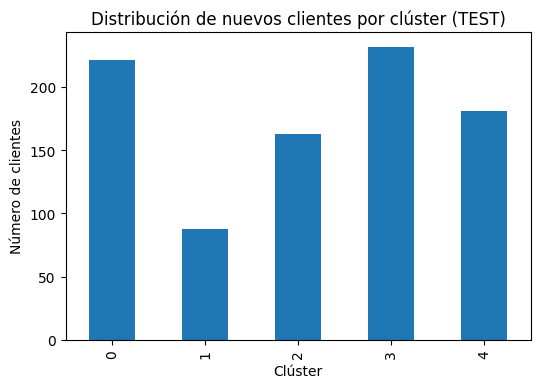

In [24]:
# APLICACIÓN DEL MODELO DE CLUSTERING A NUEVOS CLIENTES

# Cargar el conjunto de test
clientes_test = pd.read_csv(os.path.join(datos_path, "Clientes_test.csv"), sep='\t')

# Unir con la información geográfica
datos_test = pd.merge(clientes_test, zonas, on="ID_Zona", how="inner")

# Repetir el mismo preprocesamiento que en el conjunto de entrenamiento

# Conversión de fechas
datos_test['Fecha_Nacimiento'] = pd.to_datetime(datos_test['Fecha_Nacimiento'], errors='coerce', dayfirst=True)
datos_test['Fecha_Alta'] = pd.to_datetime(datos_test['Fecha_Alta'], errors='coerce', dayfirst=True)

# Cálculo de Edad y Antigüedad (manteniendo misma fecha de referencia)
fecha_referencia = pd.to_datetime("2025-01-01")
datos_test['Edad'] = (fecha_referencia - datos_test['Fecha_Nacimiento']).dt.days // 365
datos_test['Antiguedad'] = (fecha_referencia - datos_test['Fecha_Alta']).dt.days // 365

# Eliminar columnas de fecha originales
datos_test.drop(columns=['Fecha_Nacimiento', 'Fecha_Alta'], inplace=True)

# Codificación del sexo (Hombre=0, Mujer=1)
datos_test['Sexo'] = datos_test['Sexo'].map({'Hombre': 0, 'Mujer': 1})

# Eliminar identificadores
datos_test.drop(columns=['ID_Cliente', 'ID_Zona'], inplace=True)

# Eliminar las mismas variables colineales que en el entrenamiento
datos_test = datos_test.drop(columns=variables_colineales_a_eliminar, errors='ignore')

# Aplicar transformación logarítmica (en las mismas columnas que el train)
for col in log_transform_vars:
    if col in datos_test.columns:
        datos_test[col] = np.log1p(datos_test[col])

# Escalar con el mismo scaler entrenado sobre el conjunto de entrenamiento
datos_test_scaled = datos_test.copy()
datos_test_scaled[vars_to_scale] = scaler.transform(datos_test_scaled[vars_to_scale])

# Asignar clústeres a los nuevos clientes usando el modelo K-Means entrenado
datos_test_scaled['Cluster'] = kmeans_final.predict(datos_test_scaled)

# Resumen de resultados: distribución de clientes test por clúster
print("Distribución de nuevos clientes (TEST) por clúster:")
display(datos_test_scaled['Cluster'].value_counts().sort_index())

# Visualización gráfica de la distribución
plt.figure(figsize=(6,4))
datos_test_scaled['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribución de nuevos clientes por clúster (TEST)")
plt.xlabel("Clúster")
plt.ylabel("Número de clientes")
plt.show()


**Interpretación de Distribución de Nuevos Clientes por Clúster (Conjunto TEST)**

A partir de la asignación de los nuevos clientes (`Clientes_test.csv`) a los clústeres definidos en el modelo de entrenamiento, se observa la siguiente distribución:

| Clúster | Número de clientes |
|:--:|:--:|
| **0** | 221 |
| **1** | 88 |
| **2** | 163 |
| **3** | 232 |
| **4** | 181 |

Esta distribución refleja cómo los nuevos registros se integran dentro de los cinco segmentos previamente identificados, permitiendo analizar su coherencia con los perfiles observados en el conjunto de entrenamiento.

---

**Clúster 0 – Alta contratación y consumo**
- **Perfil esperado:** Clientes con elevada contratación de productos (especialmente de vehículos y otros) y gasto medio-alto. Nivel educativo bajo y predominancia de ocupaciones no cualificadas.  
- **Interpretación en TEST:** Con 221 clientes, este clúster mantiene una representación destacada. Se trata de un grupo de **alto potencial comercial**, alineado con el perfil de mayor tasa de conversión del entrenamiento (~8.9%). Representa una oportunidad clara para estrategias de fidelización y venta cruzada (*cross-selling*).

---

**Clúster 1 – Zona estable con ingresos medios**
- **Perfil esperado:** Hogares con ingresos intermedios, cobertura médica privada y mayor propiedad de vivienda. Nivel educativo equilibrado.  
- **Interpretación en TEST:** Es el grupo menos representado (88 clientes), lo que podría indicar una **menor captación reciente de clientes de clase media consolidada**. Pese a su bajo peso, sigue siendo un segmento valioso por su estabilidad económica y potencial de retención a largo plazo.

---

**Clúster 2 – Desvinculado del producto**
- **Perfil esperado:** Clientes con consumo nulo o muy bajo, mínima contratación y escasa implicación con la entidad.  
- **Interpretación en TEST:** Con 163 registros, este grupo mantiene una proporción relevante. Se espera que su nivel de interacción comercial siga siendo bajo, por lo que podría requerir **estrategias de activación o educación financiera** para aumentar su vinculación.

---

**Clúster 3 – Mayoría vulnerable con bajo consumo**
- **Perfil esperado:** Clientes con bajo nivel educativo, ocupaciones no cualificadas y bajo gasto en productos financieros.  
- **Interpretación en TEST:** Es el clúster con **mayor cantidad de nuevos clientes (232)**. Esto sugiere que los últimos clientes incorporados provienen en su mayoría de segmentos más vulnerables o con menor capacidad económica. Aunque su conversión esperada es baja (~3%), este grupo representa una **oportunidad social y de fidelización**, especialmente si se diseñan productos ajustados a sus necesidades.

---

**Clúster 4 – Perfil profesional y educativo**
- **Perfil esperado:** Clientes con formación media o superior, presencia de funcionarios y consumo intermedio.  
- **Interpretación en TEST:** Con 181 clientes, mantiene una participación estable y coherente con el modelo original. Este grupo puede ser un **segmento estratégico de crecimiento**, caracterizado por buena capacidad de respuesta comercial (~7.9% en train) y perfil propenso a servicios de valor agregado.

---

**Conclusión general**

La distribución de nuevos clientes por clúster muestra una **coherencia estructural sólida** respecto a los patrones identificados en el conjunto de entrenamiento.  
No existen clústeres vacíos ni desbalanceados, lo que confirma la **capacidad de generalización del modelo de clustering**.  
En términos estratégicos:
- Los clústeres **0 y 4** concentran clientes de alto potencial comercial.  
- El clúster **3** se consolida como el grupo más numeroso, pero de menor rentabilidad inmediata.  
- El clúster **1**, aunque minoritario, representa un perfil estable y retentivo.  
- El clúster **2** sigue siendo el más desvinculado, pero puede abordarse con campañas de activación.  

En conjunto, el modelo demuestra su **utilidad práctica para segmentar nuevos clientes**, integrándolos eficazmente en los perfiles ya definidos y facilitando la toma de decisiones comerciales basadas en datos.


## **FASE 12: Exploración de métodos alternativos**

En esta fase se evaluó la necesidad de aplicar técnicas de clustering **alternativas a K-Means**, con el objetivo de validar o complementar los resultados obtenidos previamente.

El propósito es investigar si existen patrones adicionales o agrupamientos más precisos que podrían haberse perdido al usar K-Means, especialmente si los datos presentaran formas de clústeres no esféricos, presencia significativa de ruido, o estructuras más complejas.

Inicialmente, **se consideró la posibilidad de aplicar el algoritmo DBSCAN como alternativa a K-Means**, pero debido a la distribución homogénea de las variables, **el modelo clasificó más del 98% de las observaciones como ruido** y formó únicamente pequeños grupos residuales. Por este motivo, se descartó su incorporación al análisis principal, manteniendo K-Means como método más adecuado para la estructura de este dataset.

---

**Evaluación actual con K-Means**

Tras aplicar K-Means con k=5, se ha observado lo siguiente:

- Una **segmentación clara y equilibrada** entre los diferentes clústeres.
- **Perfiles bien definidos** para cada grupo de clientes, con diferencias claras en características sociodemográficas y consumo.
- **Tasas de conversión diferenciadas**, lo cual valida la utilidad de la segmentación.
- El grupo de **outliers multivariados** fue tratado adecuadamente por separado, evitando distorsión en los centroides.

---

**Conclusión**

Dado que los resultados obtenidos con K-Means han sido satisfactorios, **NO se considera necesario aplicar métodos alternativos** como DBSCAN o Gaussian Mixture Models.

Esta decisión permite mantener la interpretabilidad del modelo y enfocar los esfuerzos en la aplicación práctica de los segmentos detectados.